In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

In [13]:
DATA_DIR = Path("/home/rauls/Desktop/VirgoBRET/cut_parquet_data")
PARQUET_FILES = sorted(DATA_DIR.glob("**/*/qtransform_features.parquet"))
RANDOM_STATE = 42

MONTH_ORDER = {"jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6, "jul": 7, "ago": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12}

In [ ]:
if len(PARQUET_FILES) == 0:
    raise FileNotFoundError(
        f"No parquet files found inside: {DATA_DIR}")

print(f"Found {len(PARQUET_FILES)} parquet files.")

dataframes = []

parquet_files = list(DATA_DIR.glob("*/*/qtransform_features.parquet"))
parquet_files.sort(key=lambda p: (int(p.parent.parent.name), MONTH_ORDER[p.parent.name]))

for file in parquet_files:
    print(f"Loading: {file}")

    df = pd.read_parquet(file)
    folder = file.parent
    
    year = int(folder.parent.name)
    month = folder.name.lower()

    image_paths = [str(folder / f"qtransform_{i:06d}.pdf") for i in range(len(df))]
    missing_images = [path for path in image_paths if not Path(path).exists()]

    if missing_images:
        raise FileNotFoundError(f"{len(missing_images)} PDF files are missing in {folder}. First missing file: {missing_images[0]}")

    df["image_path"] = image_paths
    df["source_file"] = file.name
    df["source_path"] = str(file)

    df["year"] = year
    df["month"] = month

    dataframes.append(df)

df_all = pd.concat(dataframes,ignore_index=True)
feature_columns = [col for col in df_all.columns if col.startswith("feature_")]

if len(feature_columns) == 0:
    raise ValueError("No feature_* columns found.")

X = df_all[feature_columns].to_numpy(dtype=np.float64)

Found 48 parquet files.
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jan/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/feb/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/mar/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/apr/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/may/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jun/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/jul/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/ago/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/sep/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_parquet_data/2022/oct/qtransform_features.parquet
Loading: /home/rauls/Desktop/VirgoBRET/cut_par

In [18]:
X = df_all[feature_columns].to_numpy(dtype=np.float64)
X_norm = X / 40

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_norm)
reducer = umap.UMAP(metric='manhattan', random_state=RANDOM_STATE) 

embedded = reducer.fit_transform(X_scaled)

/home/rauls/Desktop/VirgoBRET/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


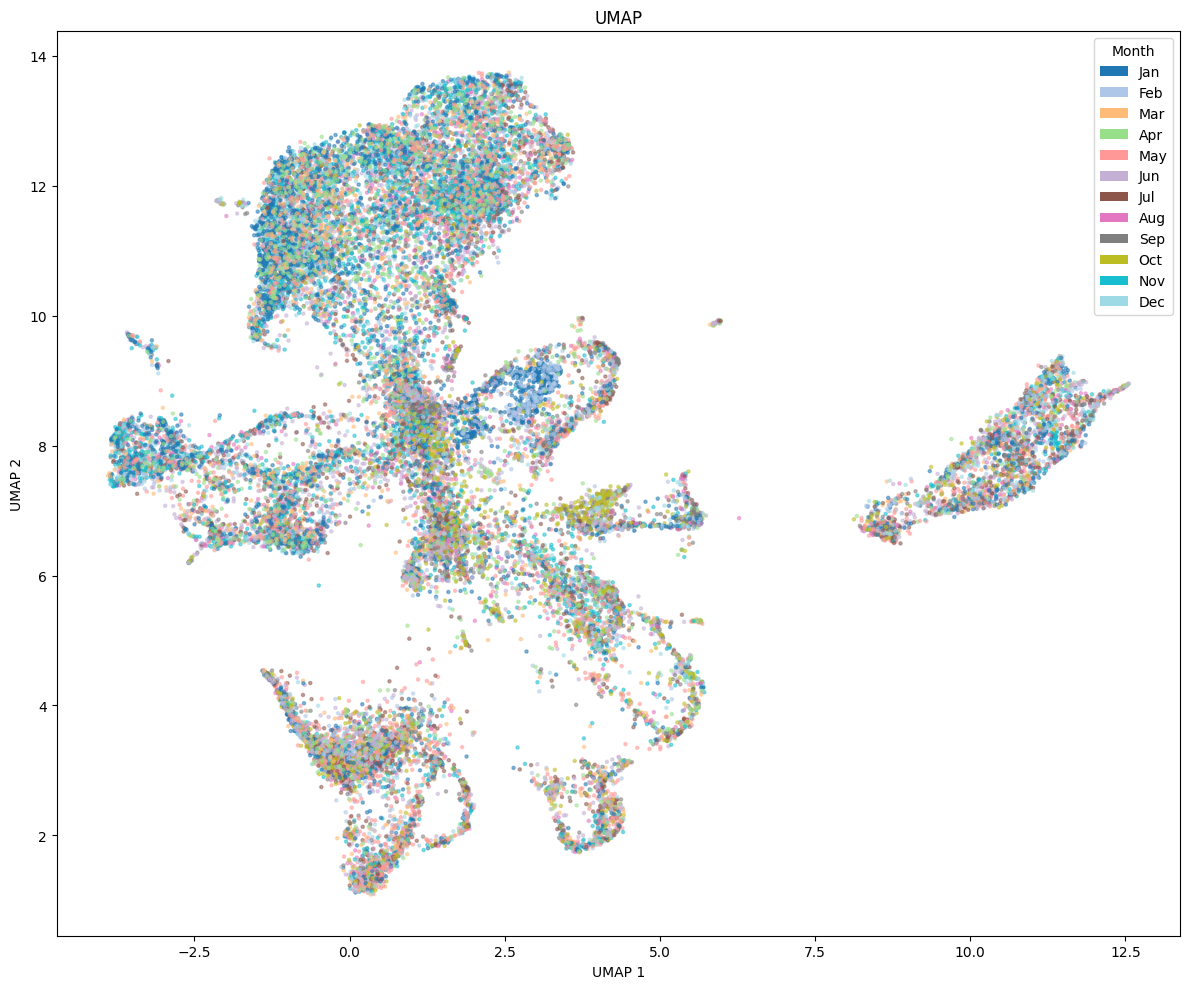

In [19]:
MONTH_NAMES = {"jan": "Jan","feb": "Feb","mar": "Mar","apr": "Apr","may": "May","jun": "Jun",
               "jul": "Jul","ago": "Aug","sep": "Sep","oct": "Oct","nov": "Nov","dec": "Dec"}

MONTHS = list(MONTH_ORDER.keys())
month_to_index = {month: i for i, month in enumerate(MONTHS)}
month_indices = df_all["month"].map(month_to_index).to_numpy()

cmap = plt.get_cmap("tab20", 12)
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(embedded[:, 0],embedded[:, 1],c=month_indices,cmap=cmap,vmin=-0.5,vmax=11.5,s=5,alpha=0.5)

legend_handles = [Patch(facecolor=cmap(i),label=MONTH_NAMES[month]) for i, month in enumerate(MONTHS)]
ax.legend(handles=legend_handles,title="Month",loc="best",markerscale=2,frameon=True)
ax.set_title(f"UMAP")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

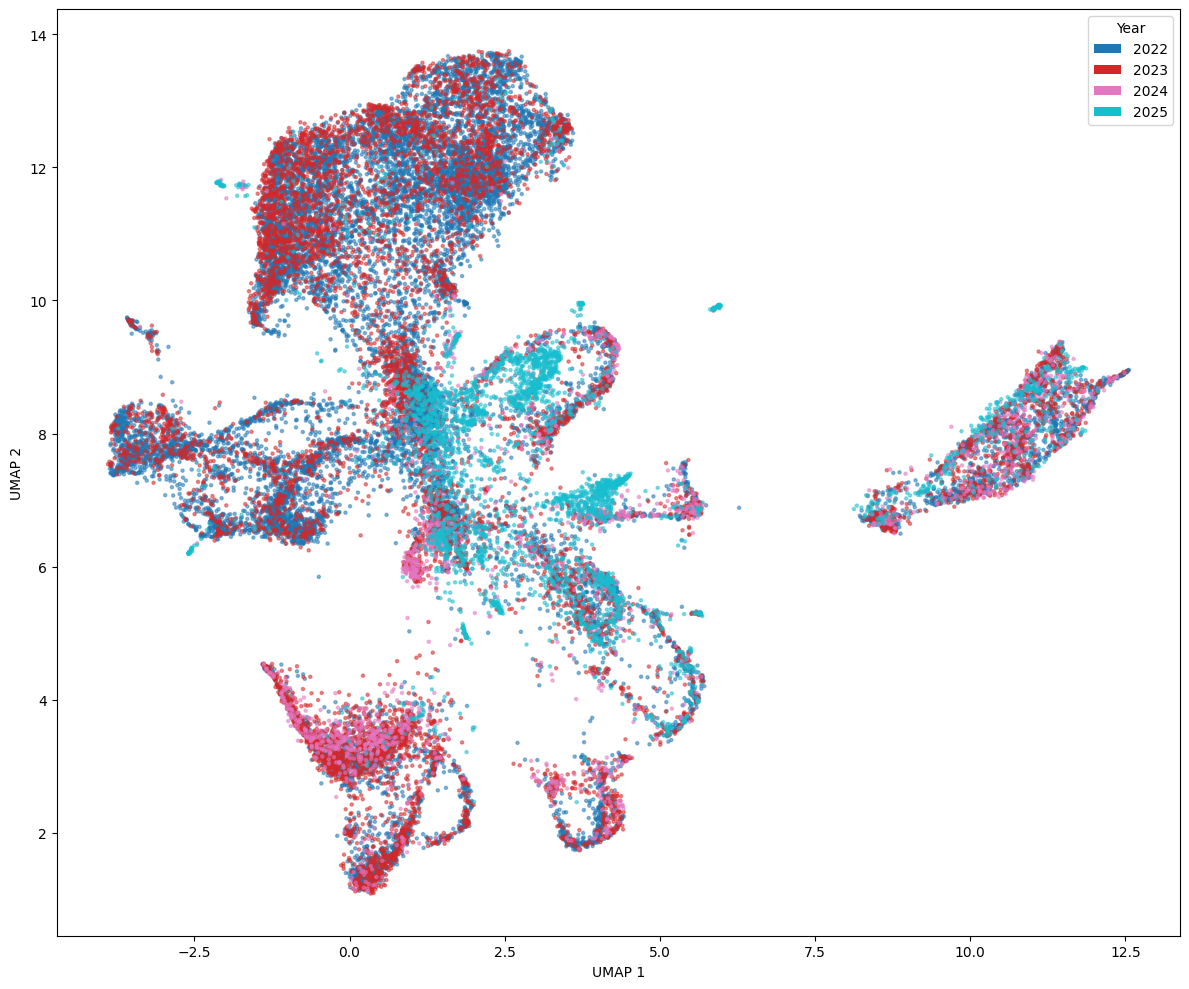

In [20]:
years = sorted(df_all["year"].unique())
year_to_index = {year: i for i, year in enumerate(years)}
year_indices = df_all["year"].map(year_to_index).to_numpy()

cmap = plt.get_cmap("tab10", len(years))
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(embedded[:, 0],embedded[:, 1],c=year_indices,cmap=cmap,vmin=-0.5,vmax=len(years) - 0.5,s=5,alpha=0.5)
legend_handles = [Patch(facecolor=cmap(i), label=str(year))for i, year in enumerate(years)]
ax.legend(handles=legend_handles,title="Year",loc="best",markerscale=2)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

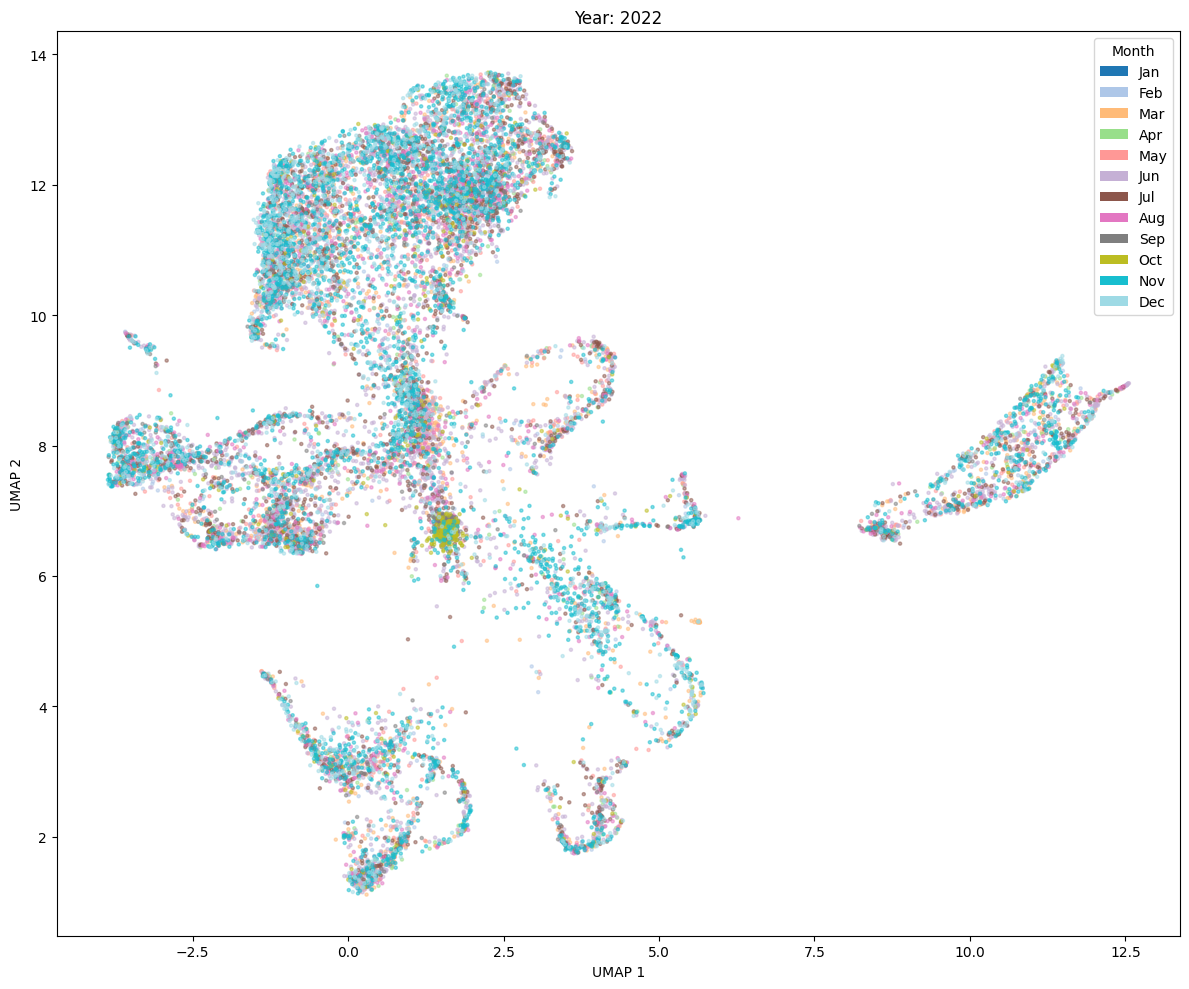

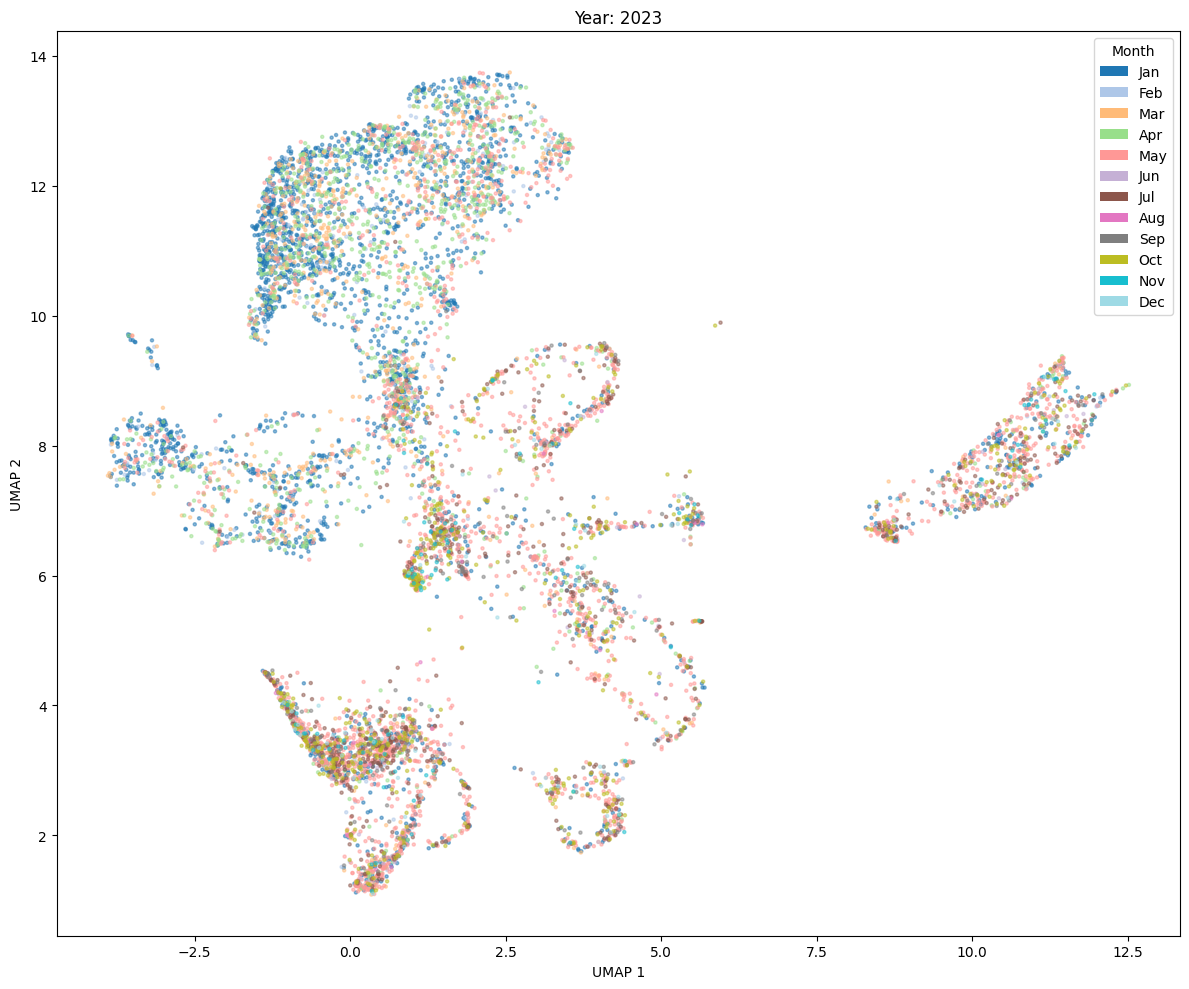

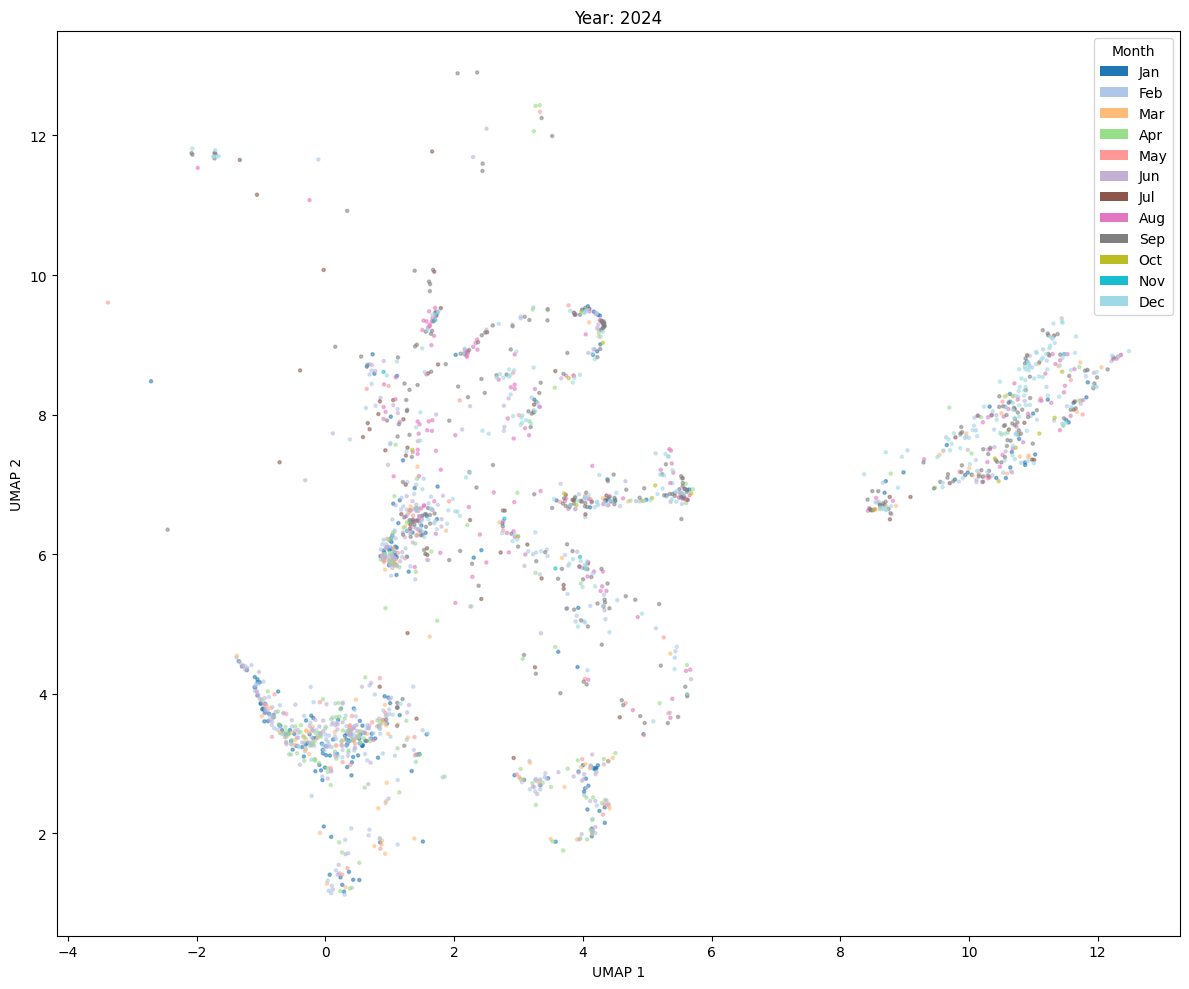

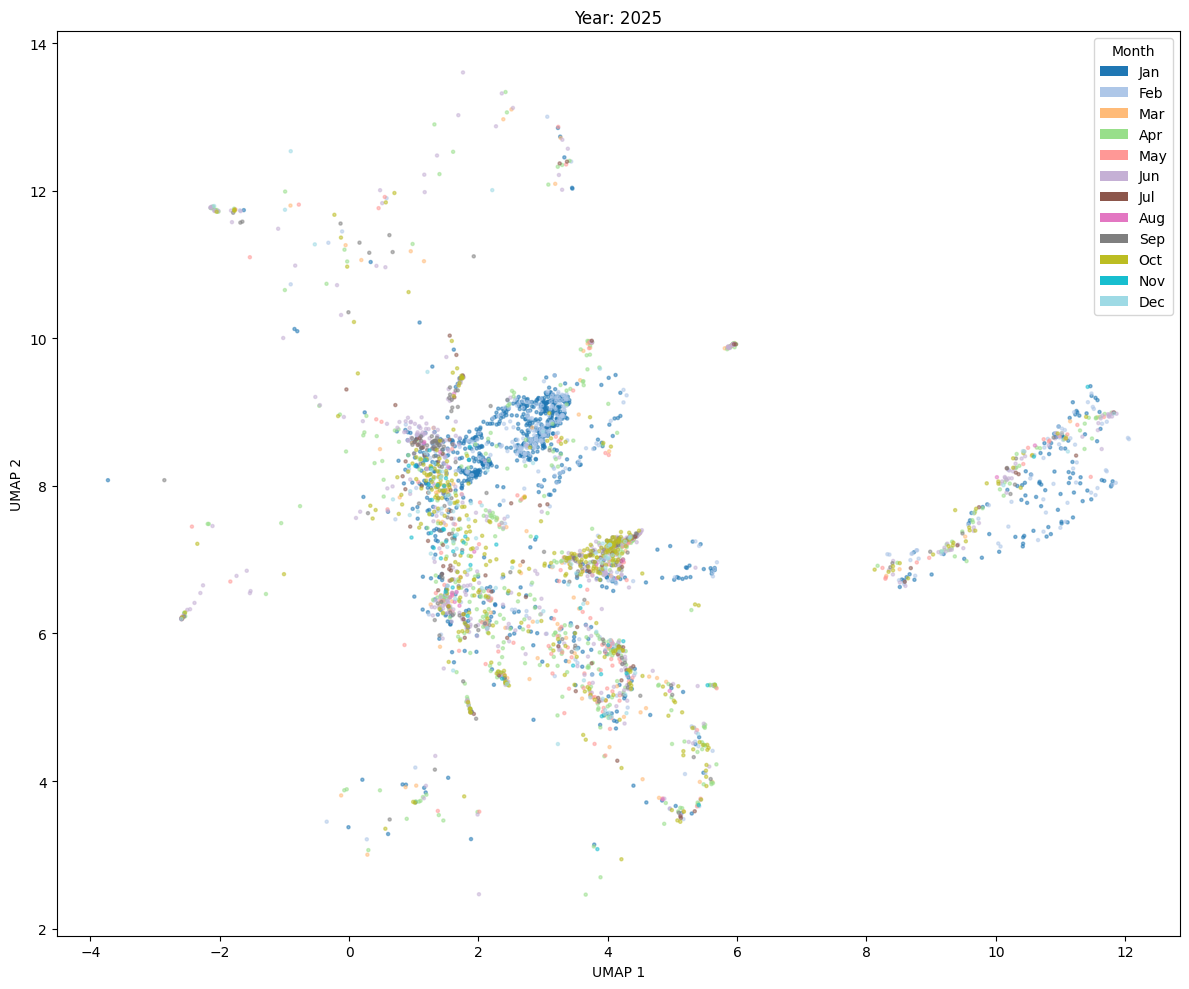

In [21]:
for year in years:
    year_mask = df_all["year"] == year
    embedded_year = embedded[year_mask]
    month_indices_year = month_indices[year_mask]

    cmap = plt.get_cmap("tab20", 12)
    fig, ax = plt.subplots(figsize=(12, 10))
    scatter = ax.scatter(embedded_year[:, 0],embedded_year[:, 1],c=month_indices_year,cmap=cmap,vmin=-0.5,vmax=11.5,s=5,alpha=0.5)

    legend_handles = [Patch(facecolor=cmap(i),label=MONTH_NAMES[month]) for i, month in enumerate(MONTHS)]
    ax.legend(handles=legend_handles,title="Month",loc="best",markerscale=2,frameon=True)
    ax.set_title(f"Year: {year}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    plt.show()

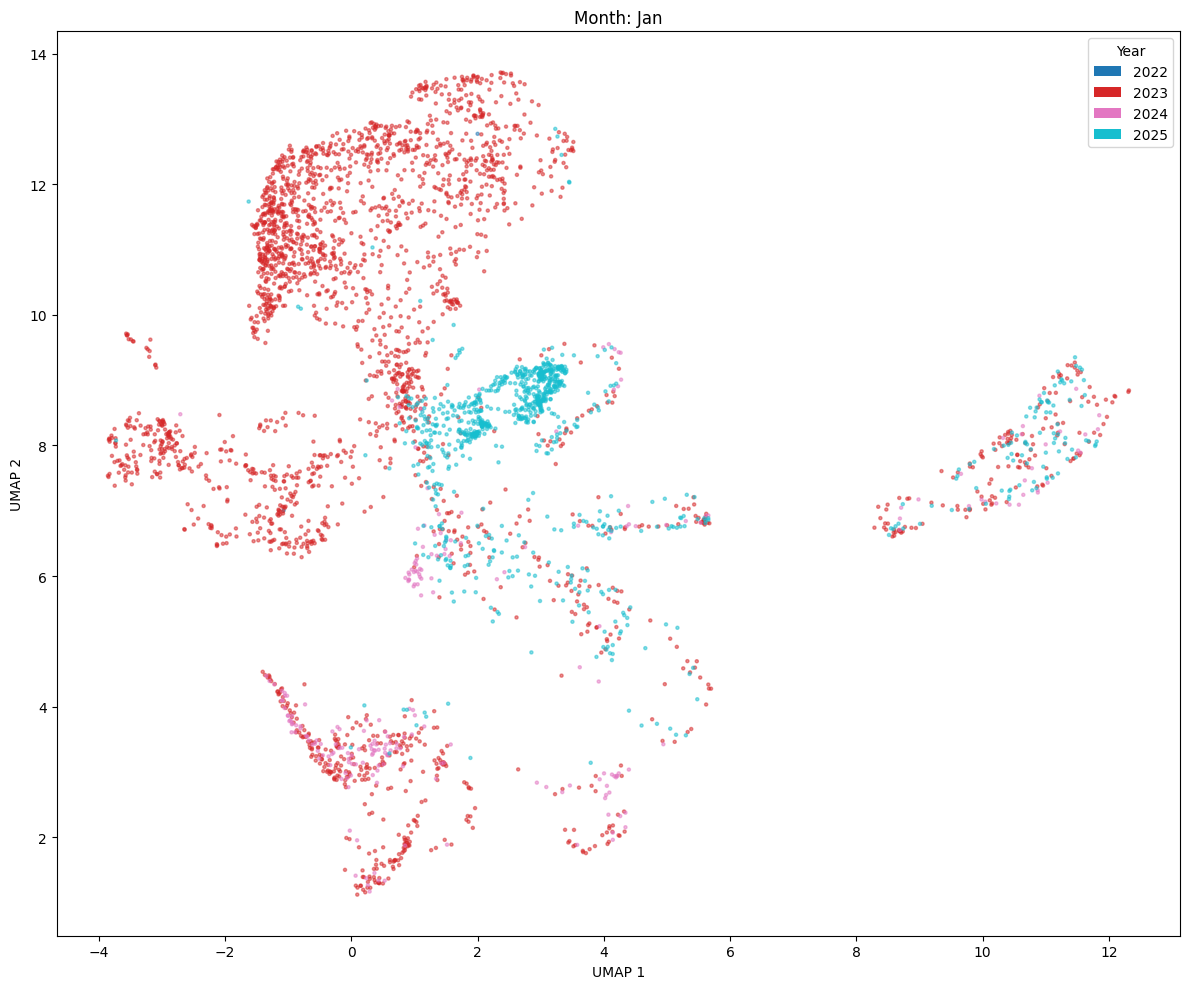

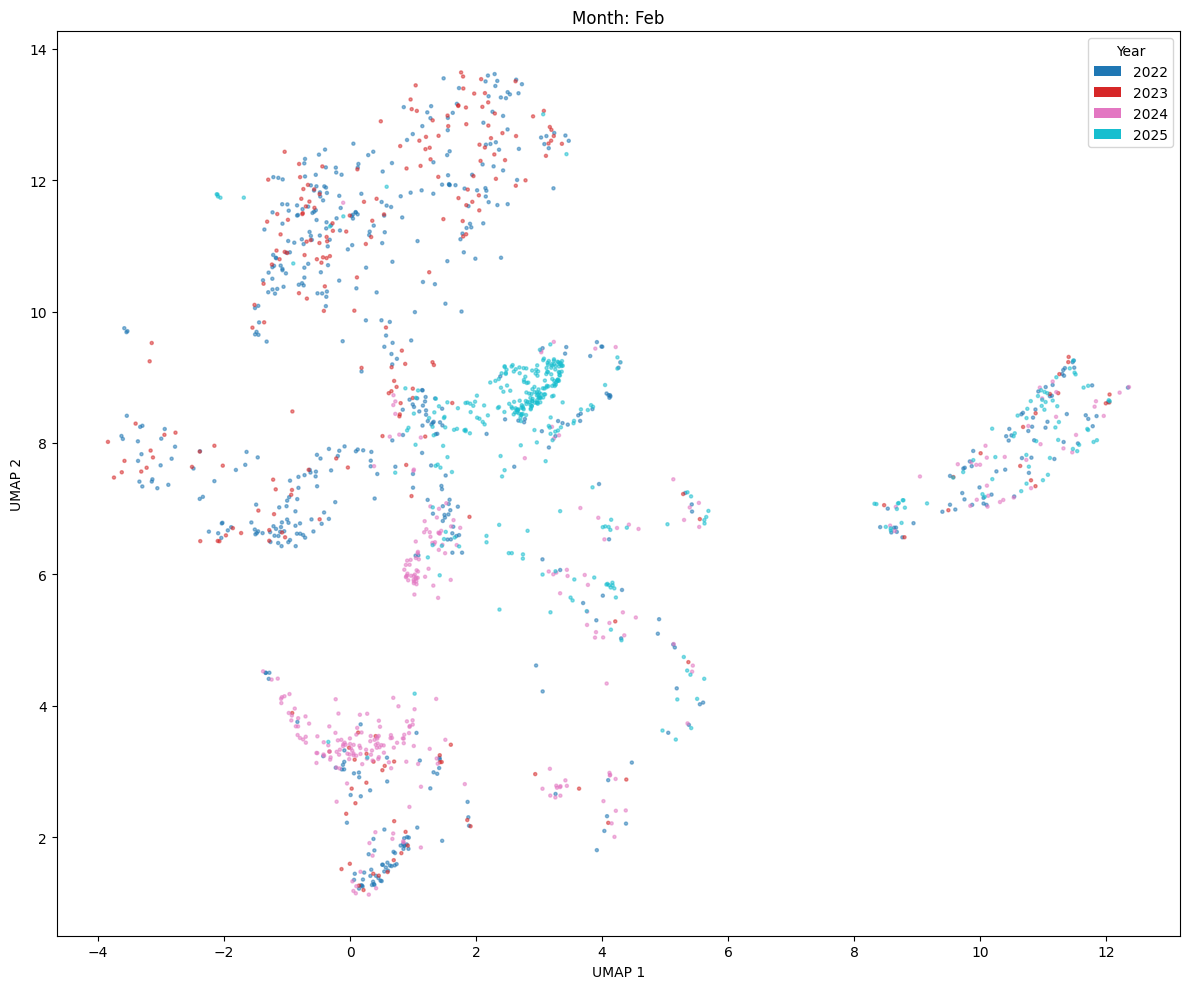

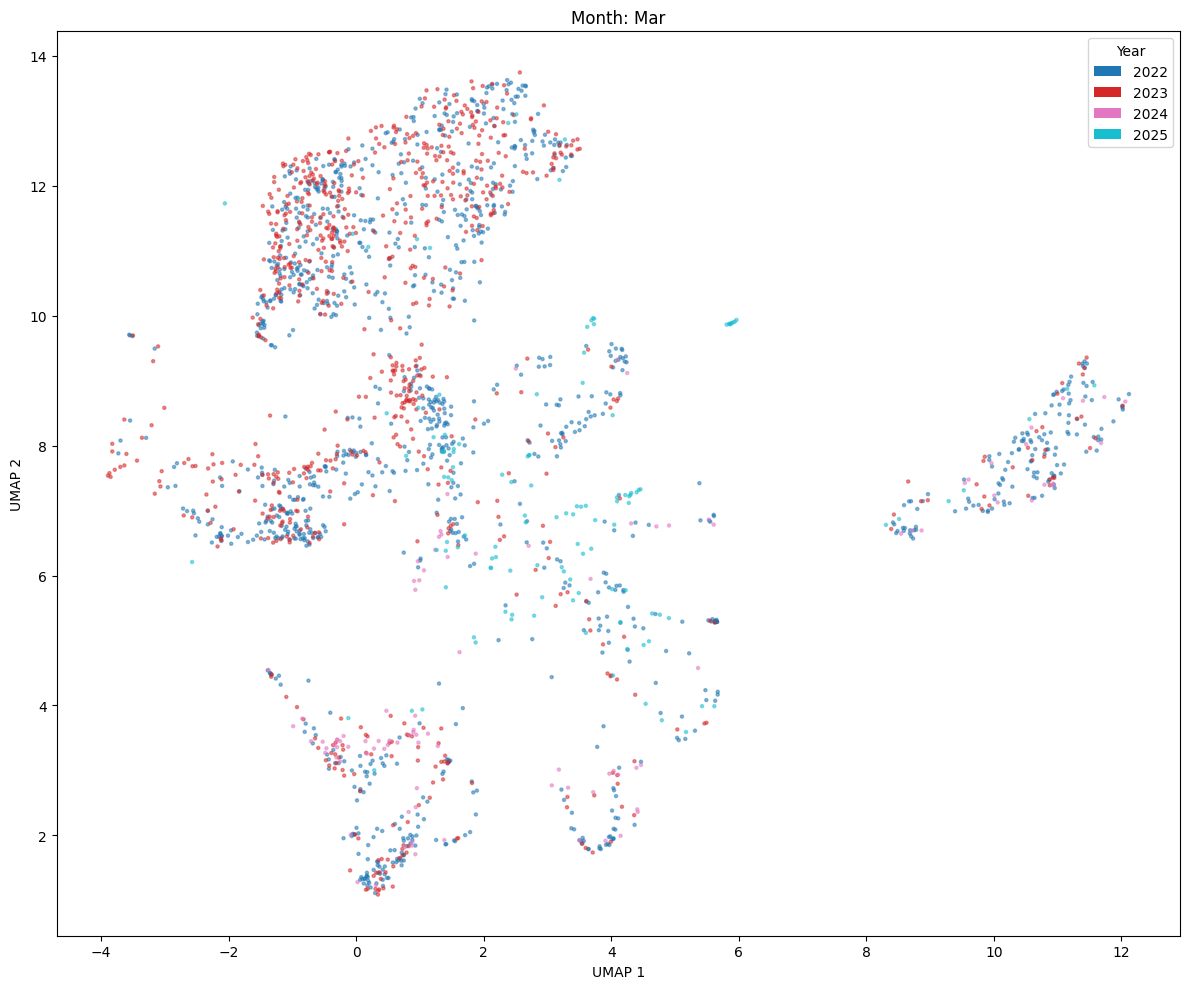

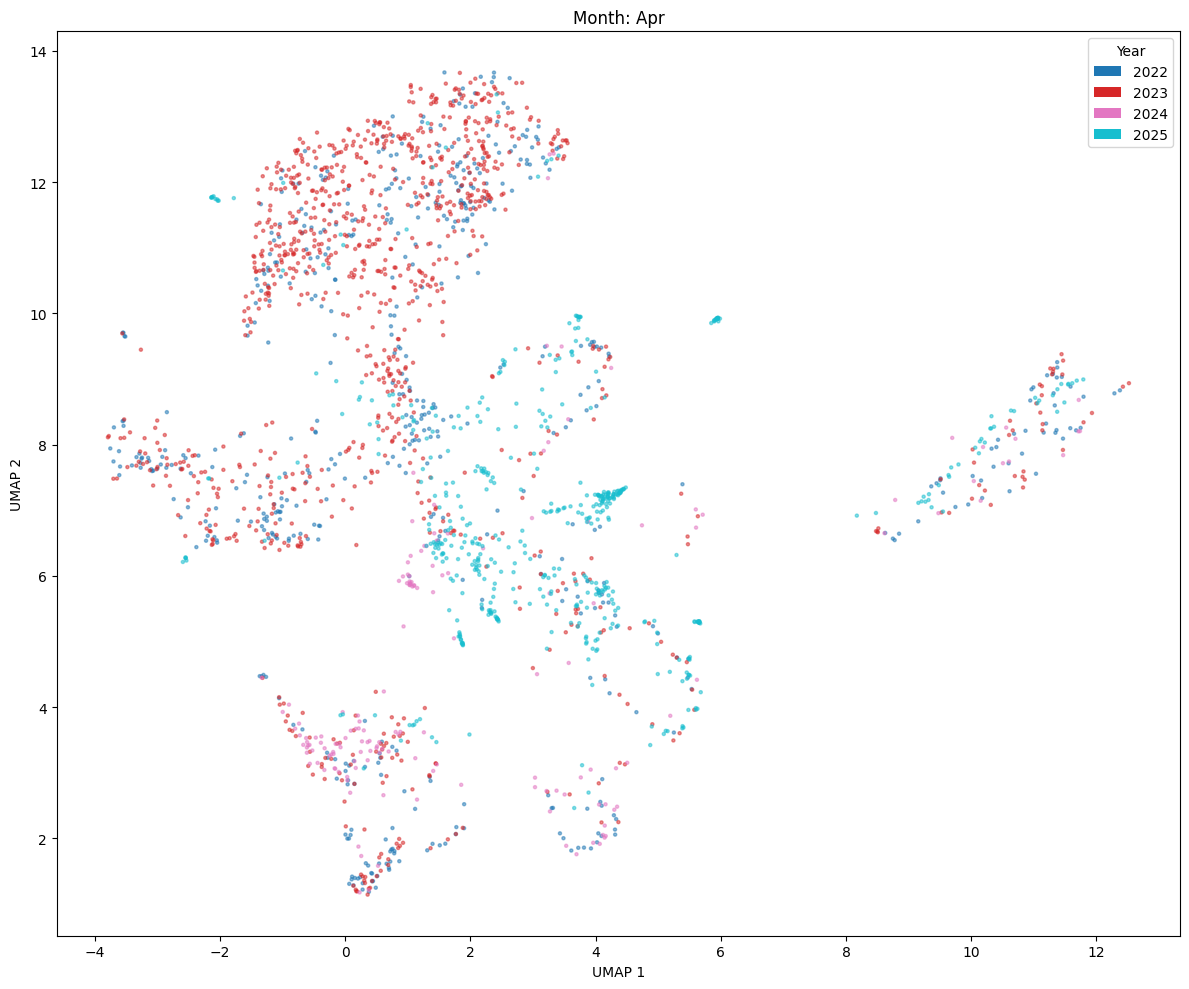

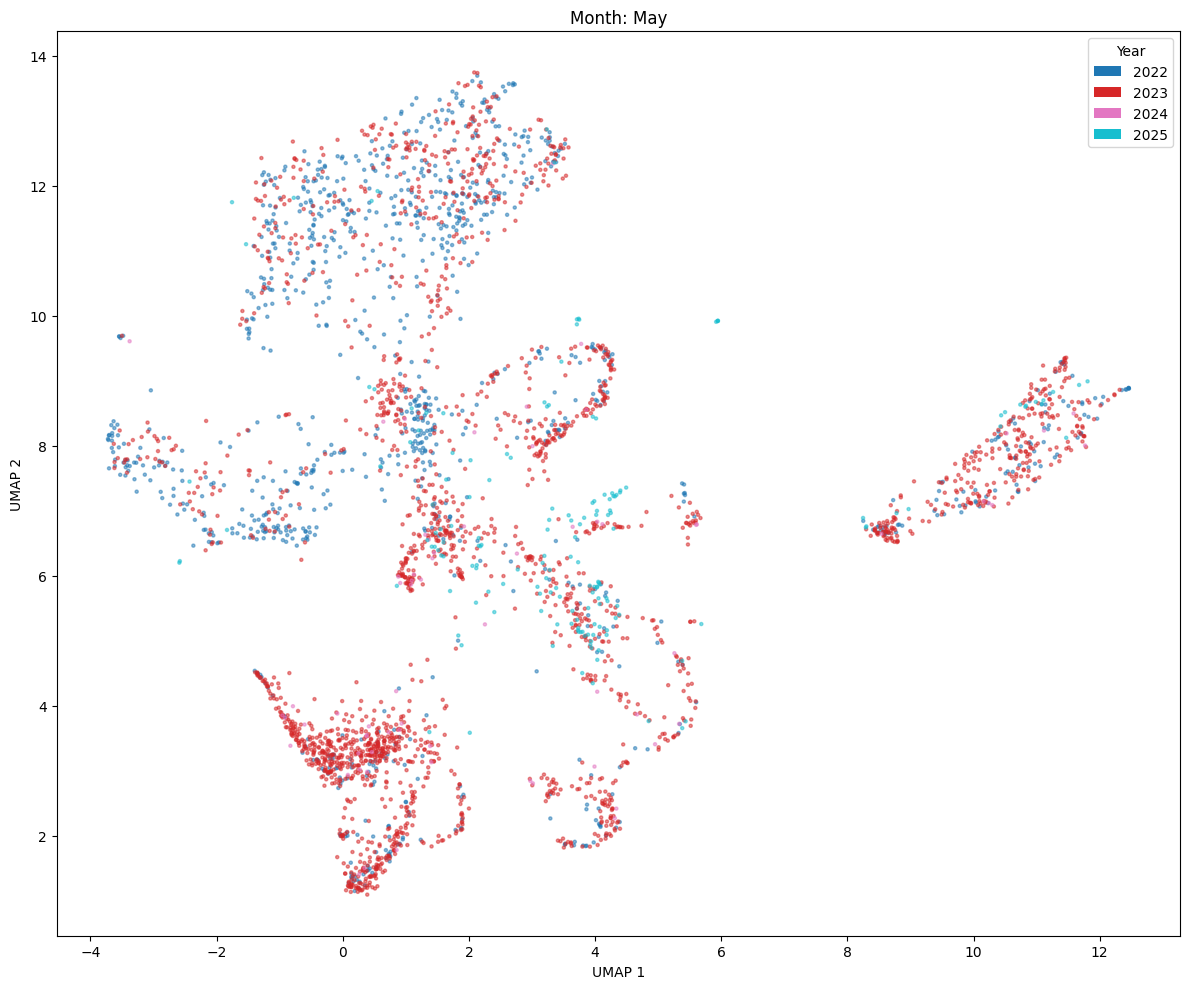

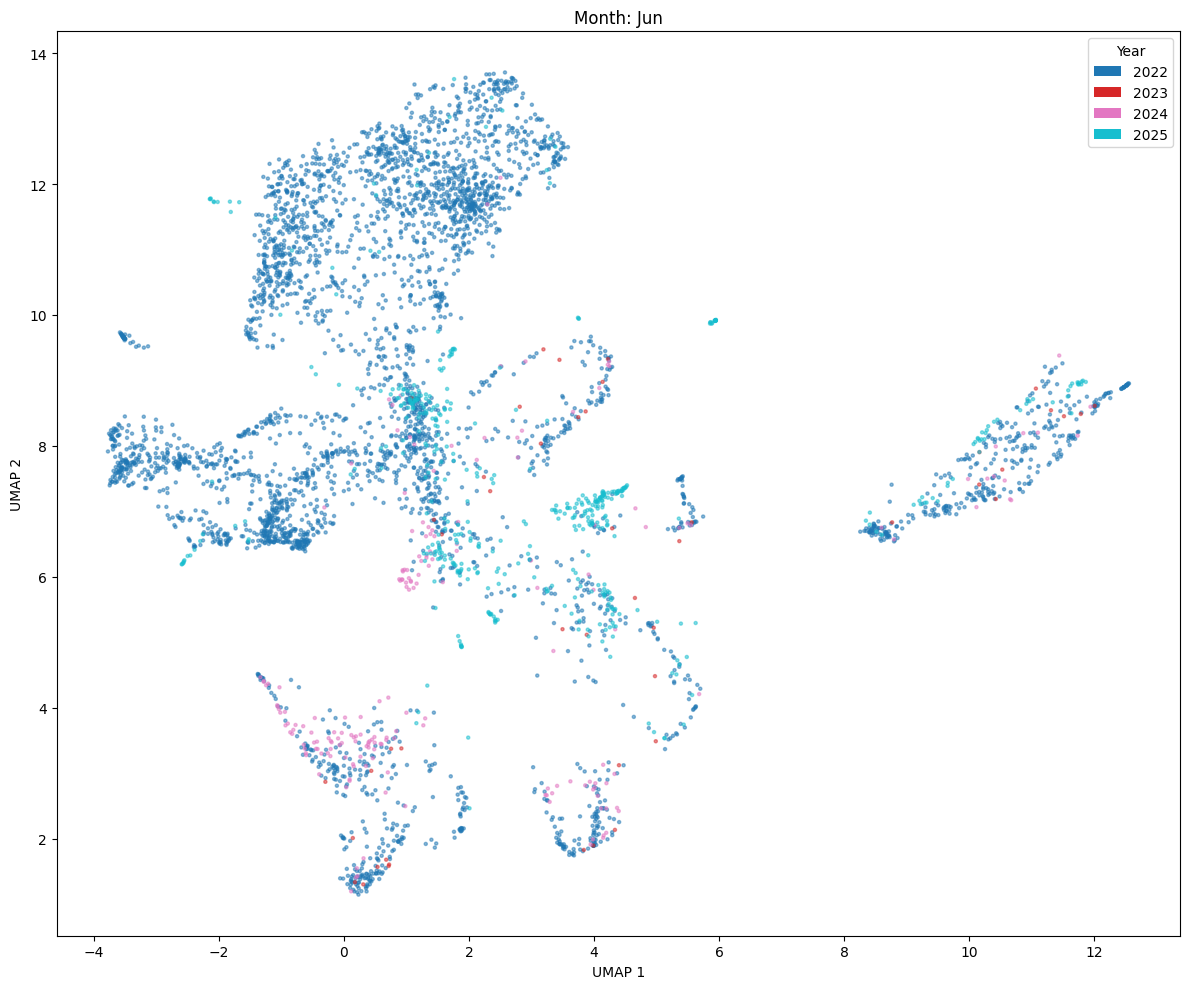

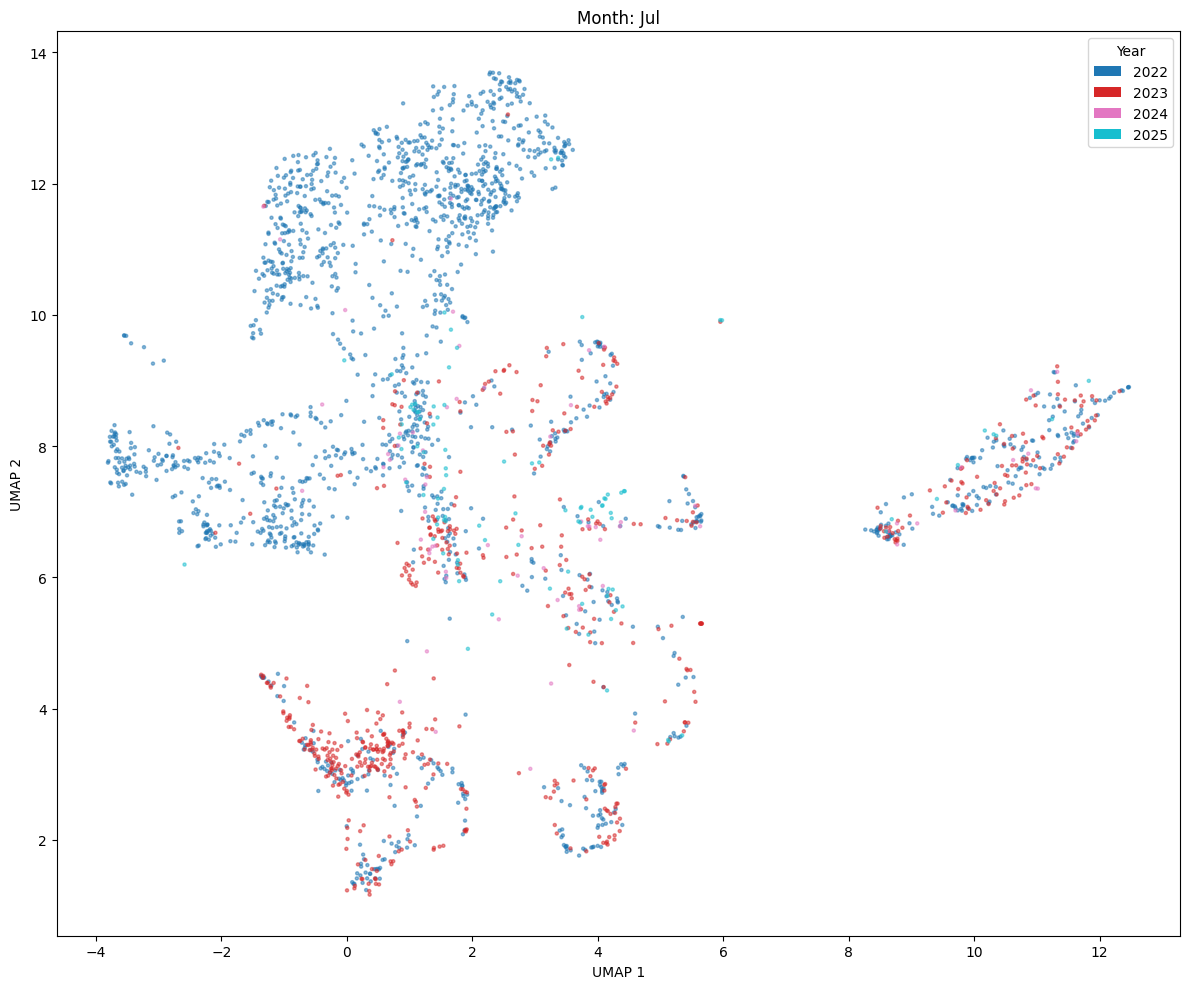

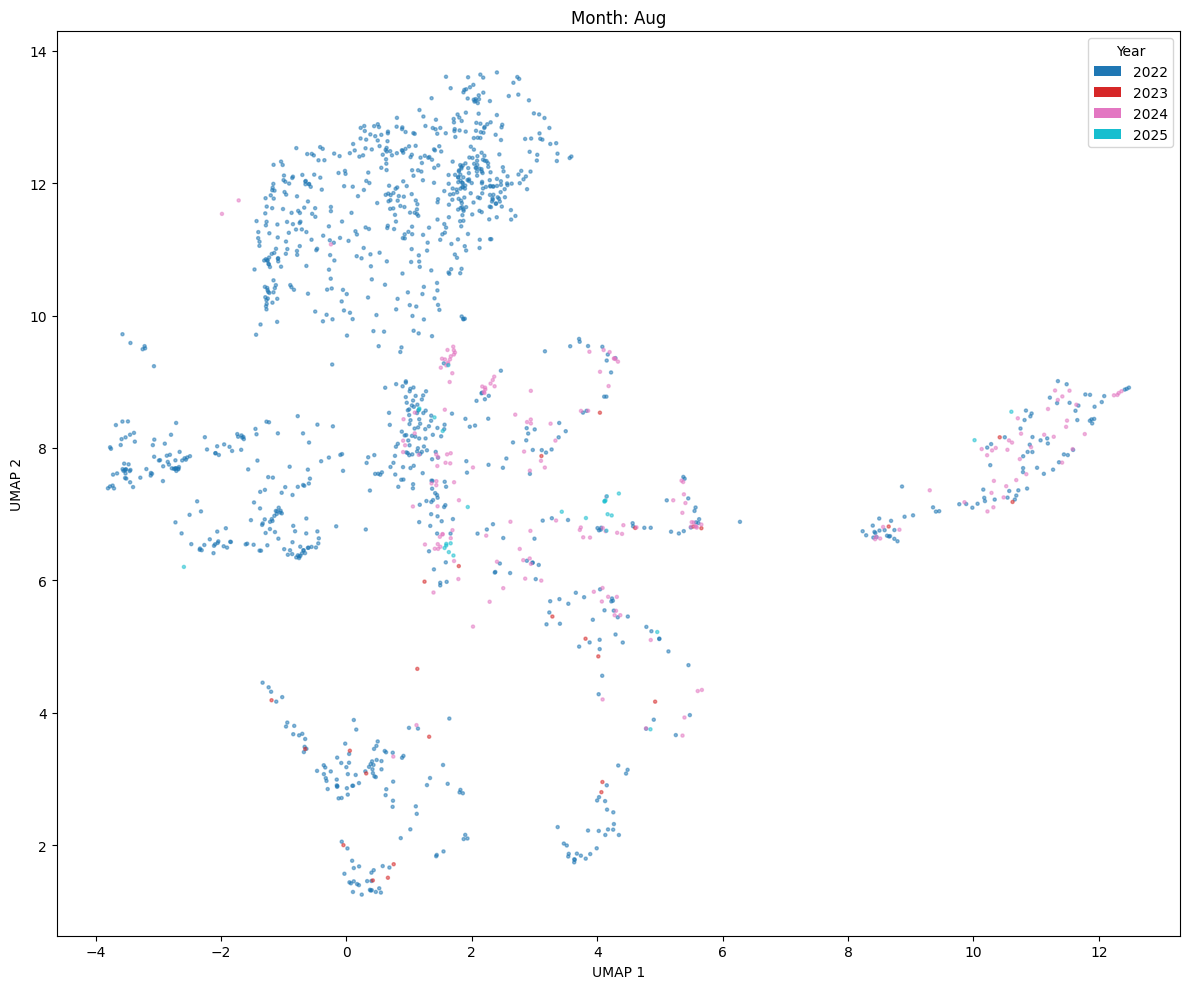

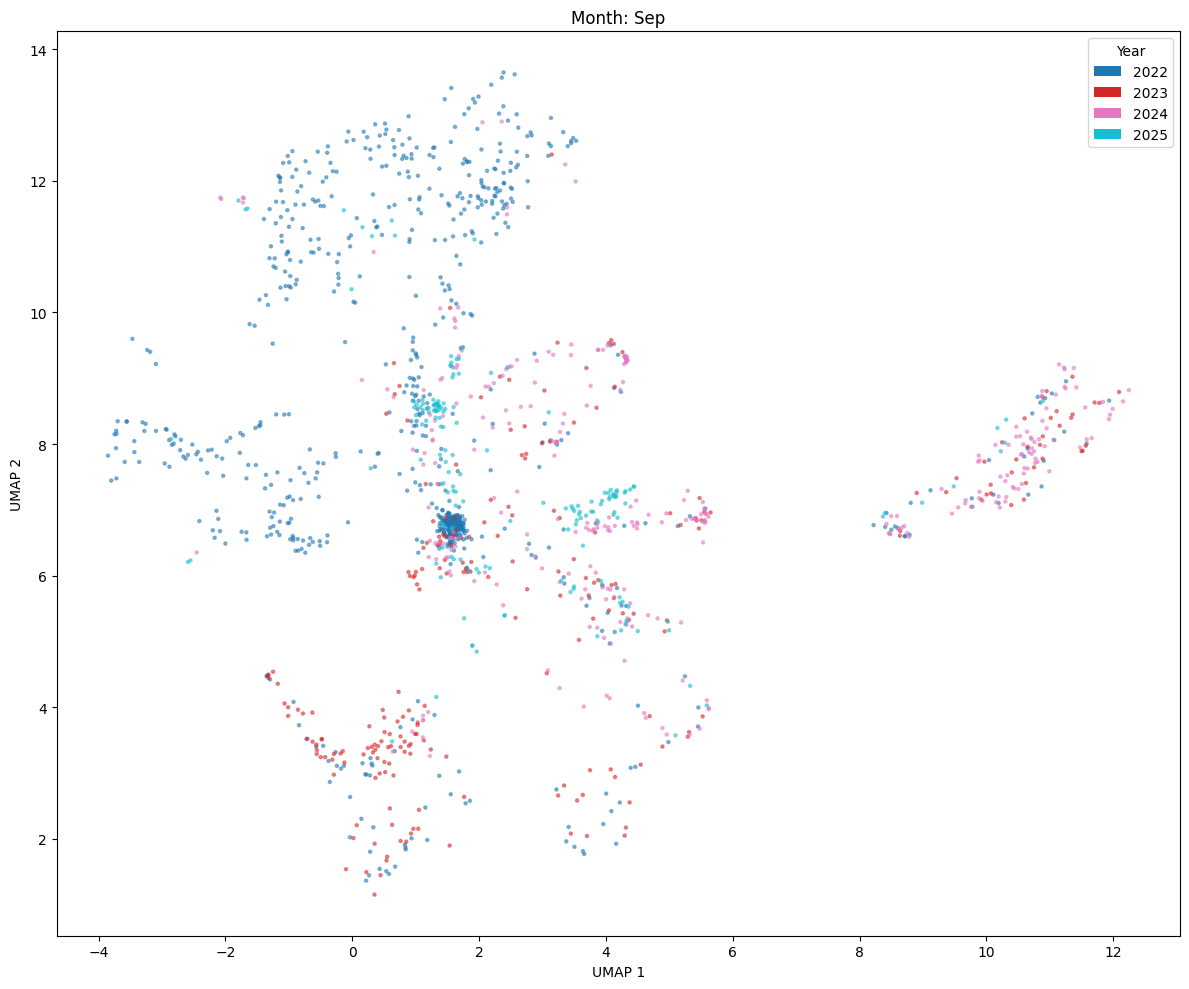

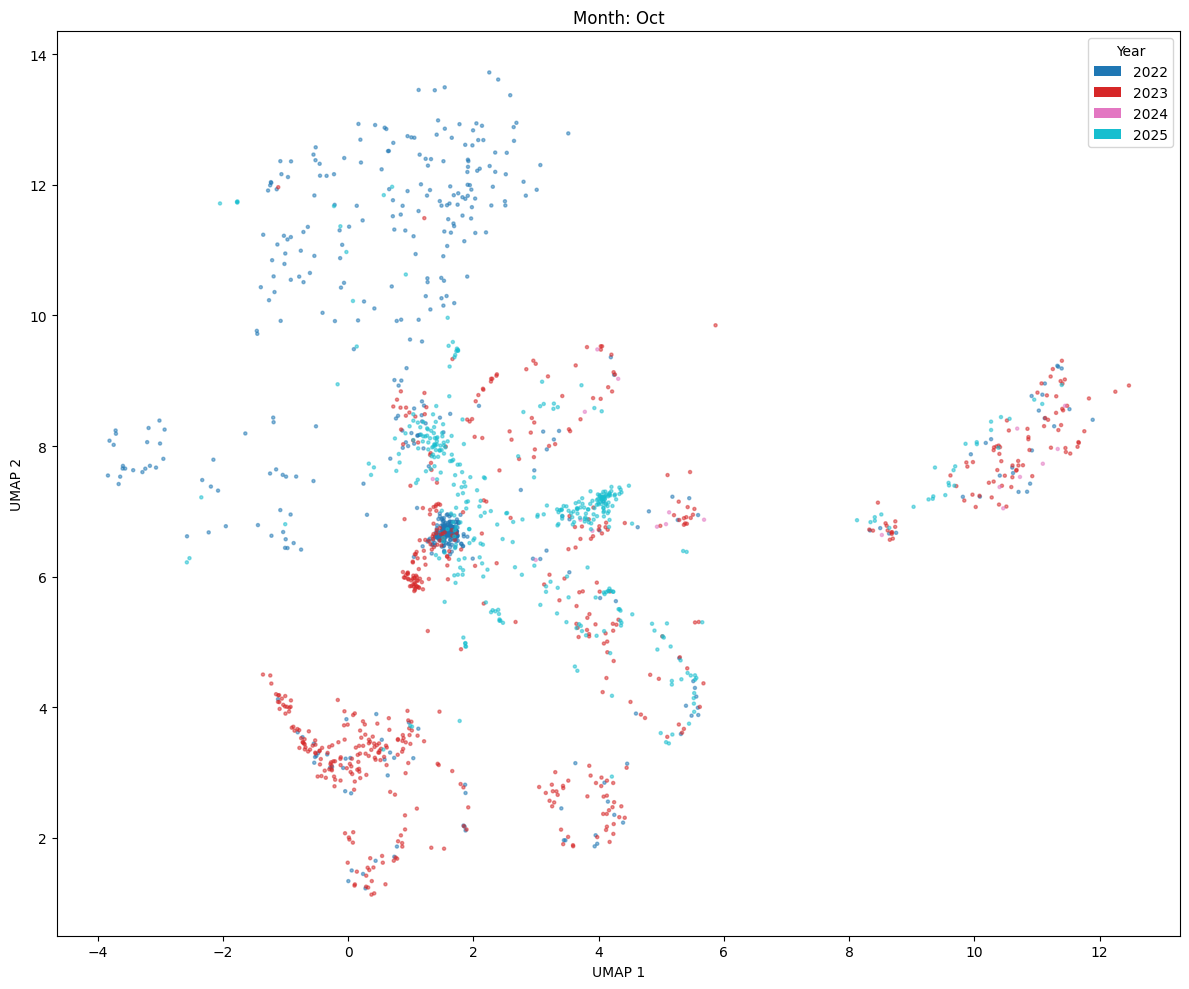

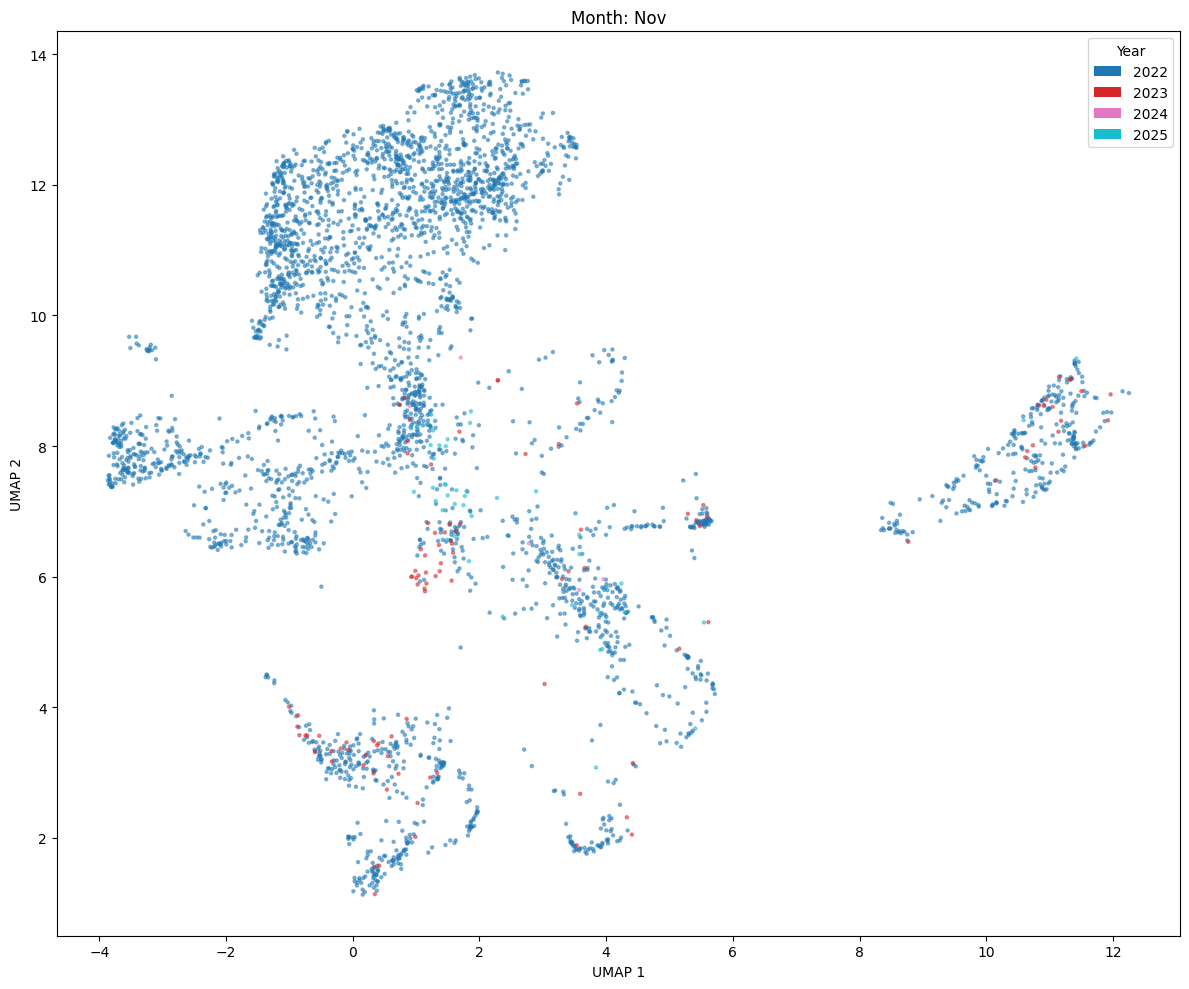

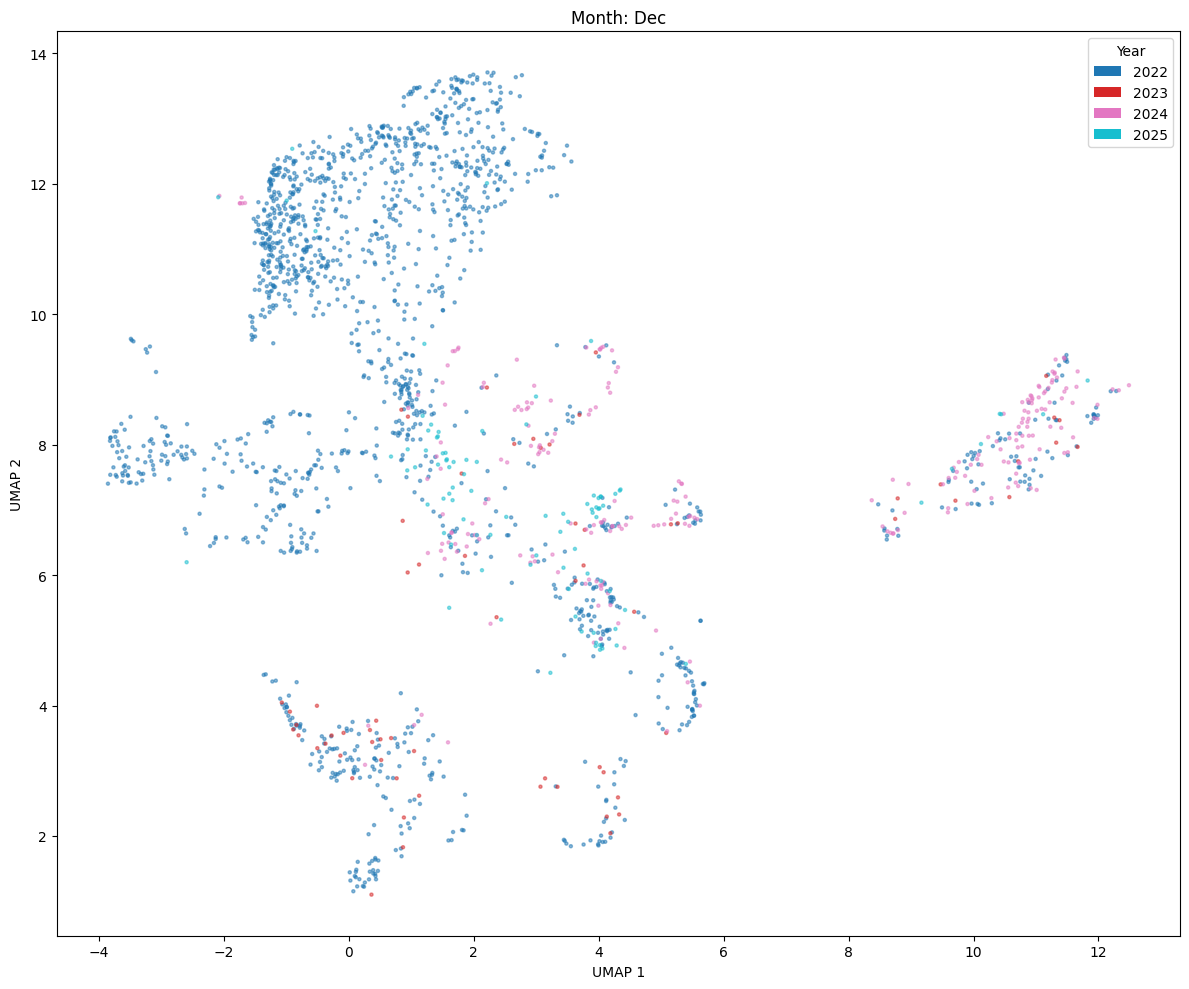

In [24]:
for month in MONTHS:
    month_mask = df_all["month"] == month
    embedded_month = embedded[month_mask]
    year_indices_month = year_indices[month_mask]

    cmap = plt.get_cmap("tab10", len(years))
    fig, ax = plt.subplots(figsize=(12, 10))
    scatter = ax.scatter(embedded_month[:, 0],embedded_month[:, 1],c=year_indices_month,cmap=cmap,vmin=-0.5,vmax=len(years) - 0.5,s=5,alpha=0.5)

    legend_handles = [Patch(facecolor=cmap(i), label=str(year))for i, year in enumerate(years)]
    ax.legend(handles=legend_handles,title="Year",loc="best",markerscale=2)
    ax.set_title(f"Month: {MONTH_NAMES[month]}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    plt.show()

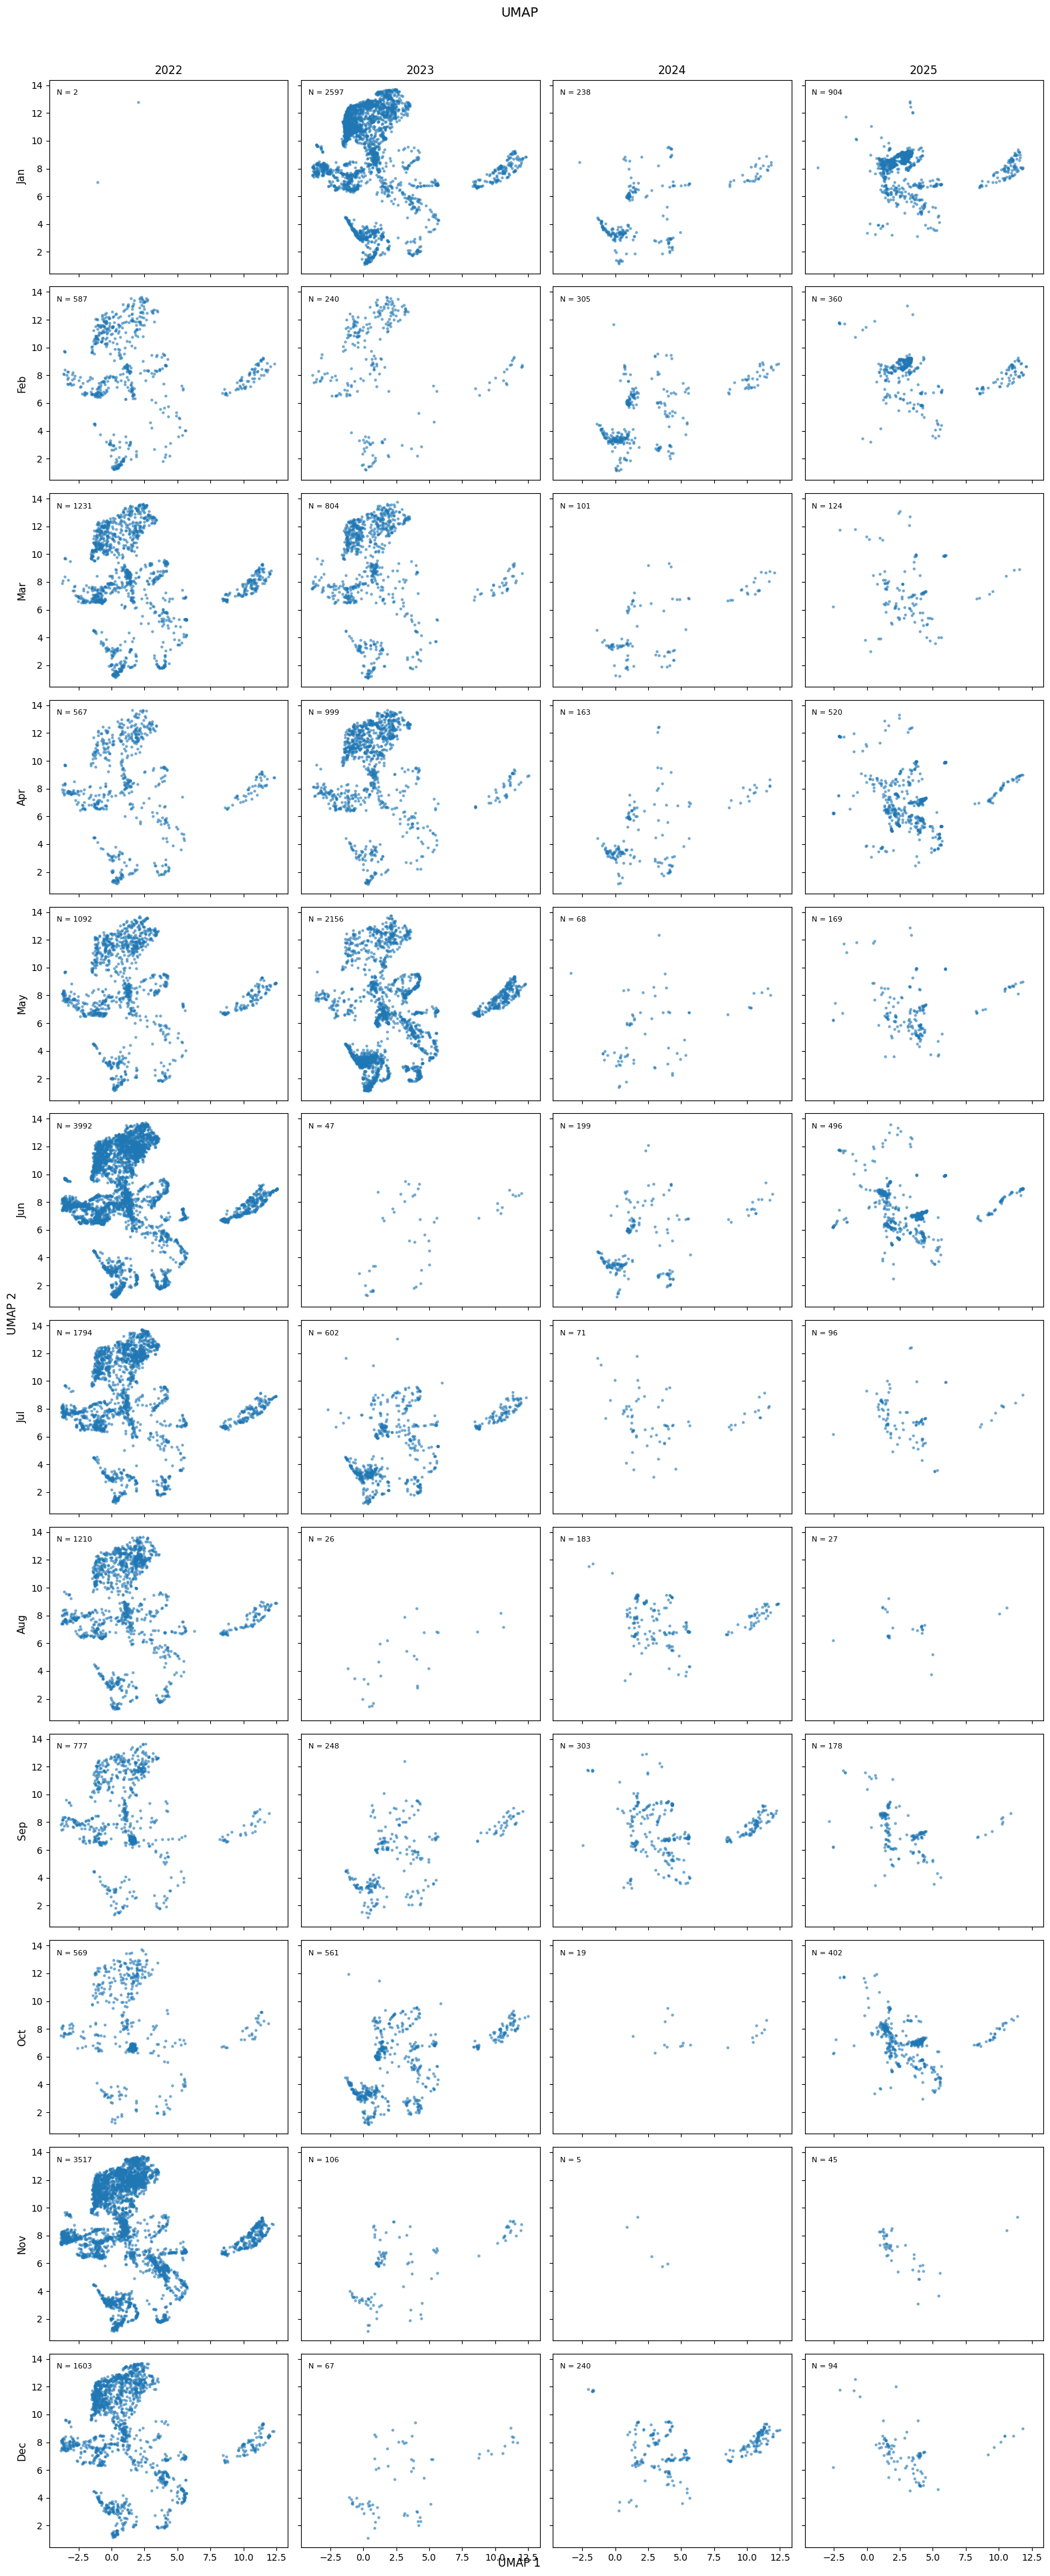

In [25]:
YEARS = sorted(df_all["year"].unique())

n_rows = len(MONTHS)
n_cols = len(YEARS)

x_min, x_max = embedded[:, 0].min(), embedded[:, 0].max()
y_min, y_max = embedded[:, 1].min(), embedded[:, 1].max()

x_margin = 0.05 * (x_max - x_min)
y_margin = 0.05 * (y_max - y_min)

x_min -= x_margin
x_max += x_margin

y_min -= y_margin
y_max += y_margin


fig, axes = plt.subplots(n_rows,n_cols,figsize=(4 * n_cols, 3.2 * n_rows), sharex=True,sharey=True,squeeze=False)

for row, month in enumerate(MONTHS):
    for col, year in enumerate(YEARS):
        ax = axes[row, col]
        mask = ((df_all["year"] == year) &(df_all["month"] == month))
        points = embedded[mask.to_numpy()]

        if len(points) > 0:
            ax.scatter(points[:, 0],points[:, 1],s=5,alpha=0.5)

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        if col == 0:
            ax.set_ylabel(MONTH_NAMES[month],fontsize=11)

        if row == 0:
            ax.set_title(str(year),fontsize=12)

        ax.text(0.03,0.95,f"N = {len(points)}",transform=ax.transAxes,ha="left",va="top",fontsize=8)

fig.supxlabel("UMAP 1")
fig.supylabel("UMAP 2")

fig.suptitle(f"UMAP",y=1.01,fontsize=14)

plt.tight_layout()
plt.savefig("UMAP_seasonal_overview.pdf")
plt.show()